In [1]:
# Imports
from matplotlib.animation import FuncAnimation
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.signal import resample
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import pandas as pd
import numpy as np
import random
import json

In [2]:
# Loading Marker Data
data = pd.read_parquet("../data/pitching_data.parquet")
data = data.drop(columns = ['residual'])

In [3]:
# Load in pitch_marker_mapping
with open("../data/pitch_marker_mapping.json", 'r') as f:
    pitch_marker_mapping = json.load(f)

# Unroll the JSON mapping into a DataFrame
mapping_records = []
for pitch_key, labels in pitch_marker_mapping.items():
    for marker_id, marker_label in enumerate(labels):
        mapping_records.append({
            "pitch_key": pitch_key,
            "markerID": marker_id,
            "markerLabel": marker_label
        })
mapping_df = pd.DataFrame(mapping_records)
mapping_df.head(2)

,pitch_key,markerID,markerLabel
0,000002_003034_002,0,C7
1,000002_003034_002,1,CLAV


In [4]:
# Create a key to merge data with marker mapping
data['pitch_key'] = (
    data['userID'].astype(str) + '_' +
    data['sessionID'].astype(str) + '_' +
    data['pitchNum'].astype(str)
)

# Merge data with marker mapping
data = pd.merge(
    data,
    mapping_df,
    on=['pitch_key', 'markerID'],
    how='inner' # Use 'inner' to keep only markers that have a label
)

# Drop original ID, replace and rename with label
data = data.drop(columns=['markerID'])
data['markerLabel'] = data['markerLabel'].str.split('_').str[-1]
data = data.rename(columns={'markerLabel': 'markerID'})
data.head(2)

,userID,sessionID,height,weight,pitchNum,pitchType,pitchSpeed,frame,x,y,z,pitch_key,markerID
0,000002,003034,73,207,002,FF,80.9,0,0.003564,-0.068032,1.581415,000002_003034_002,C7
1,000002,003034,73,207,002,FF,80.9,0,0.057339,-0.186507,1.495219,000002_003034_002,CLAV


In [5]:
# Loading points of interest data, which contains pitcher handedness
poi_metrics = pd.read_csv("../data/poi_metrics.csv")[["session_pitch", "session", "p_throws", "pitch_speed_mph"]]
poi_metrics["session_key"] = poi_metrics['session'].astype(str)
poi_metrics_unique = poi_metrics[["session_key", "p_throws"]].drop_duplicates()

# Merging marker data with pitcher handedness data
data["session_key"] = (data["sessionID"].astype(str).str.lstrip("0"))
data = data.merge(
    poi_metrics_unique,
    on = "session_key",
    how = "left"
)

# Mirror lefties about they y-axis
data.loc[data['p_throws'] == 'L', 'y'] *= -1
data.head(2)

,userID,sessionID,height,weight,pitchNum,pitchType,pitchSpeed,frame,x,y,z,pitch_key,markerID,session_key,p_throws
0,000002,003034,73,207,002,FF,80.9,0,0.003564,-0.068032,1.581415,000002_003034_002,C7,3034,R
1,000002,003034,73,207,002,FF,80.9,0,0.057339,-0.186507,1.495219,000002_003034_002,CLAV,3034,R


In [6]:
# Getting pivot table
pivot_df = data.pivot(
    index = ["userID", "sessionID", "pitchNum", "height", "weight", "frame", "pitchType", "pitchSpeed"],
    columns = "markerID",
    values = ["x", "y", "z"]
)

# Put columns into single layer
pivot_df.columns = [f"{coord}_marker{marker}" for coord, marker in pivot_df.columns]
pivot_df = pivot_df.dropna()
pivot_df.head(2)

x_markerC7  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed               
000511 001688    003      78     235    0     FF        93.1          0.081724   
                                        1     FF        93.1          0.081674   

                                                                    x_markerCLAV  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed                 
000511 001688    003      78     235    0     FF        93.1            0.154192   
                                        1     FF        93.1            0.153949   

                                                                    x_markerLANK  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed                 
000511 001688    003      78     235    0     FF        93.1            0.269110   
                                        1     FF        93.1            0.269096   

                                                                    x_markerLASI  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed                 
000511 001688    003      78     235    0     FF        93.1            0.302442   
                                        1     FF        93.1            0.302310   

                                                                    x_markerLBAK  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed                 
000511 001688    003      78     235    0     FF        93.1            0.150238   
                                        1     FF        93.1            0.150415   

                                                                    x_markerLBHD  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed                 
000511 001688    003      78     235    0     FF        93.1            0.094892   
                                        1     FF        93.1            0.094827   

                                                                    x_markerLELB  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed                 
000511 001688    003      78     235    0     FF        93.1            0.430795   
                                        1     FF        93.1            0.431003   

                                                                    x_markerLFHD  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed                 
000511 001688    003      78     235    0     FF        93.1            0.204421   
                                        1     FF        93.1            0.204310   

                                                                    x_markerLFIN  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed                 
000511 001688    003      78     235    0     FF        93.1            0.330168   
                                        1     FF        93.1            0.329869   

                                                                    x_markerLFRM  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed                 
000511 001688    003      78     235    0     FF        93.1            0.391722   
                                        1     FF        93.1            0.391775   

                                                                    ...  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed  ...   
000511 001688    003      78     235    0     FF        93.1        ...   
                                        1     FF        93.1        ...   

                                                                    z_markerRPSI  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed                 
000511 001688    003      78     235    0     FF        93.1            1.164060   
                                        1     FF        93.1            1.164092   

                                                                    

In [ ]:
# Get y-coordinate column names
y_cols = [c for c in pivot_df.columns if c.startswith("y_marker")]

# Compute each pitch's first-frame mean Y
pivot_df_centered = pivot_df.copy()
first_frame_mean_y = (
    pivot_df_centered
    .groupby(["userID", "sessionID", "pitchNum"])[y_cols]
    .transform(lambda g: g.iloc[0].mean())
)

# Subtract that baseline so each pitch starts at mean(y)=0
pivot_df_centered[y_cols] = pivot_df_centered[y_cols] - first_frame_mean_y

In [8]:
# Doing PCA with 3 components
X = pivot_df_centered.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components = 3)

# Fitting the PCA
scores = pca.fit_transform(X_scaled)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_)*100)

Cumulative explained variance: [47.56883063 61.36042608 70.36381601]


In [9]:
# Making dataframe to hold reconstruction data
scores_df = pivot_df_centered.copy().reset_index()

for i in range(scores.shape[1]):
    scores_df[f"PC{i+1}"] = scores[:, i]

# Drop marker columns for clarity
feature_cols = [col for col in scores_df.columns if col.startswith(('x_', 'y_', 'z_'))]
scores_df = scores_df.drop(columns = feature_cols)
scores_df.head(2)

,userID,sessionID,pitchNum,height,weight,frame,pitchType,pitchSpeed,PC1,PC2,PC3
0,000511,001688,003,78,235,0,FF,93.1,-7.549763,-2.155994,1.166974
1,000511,001688,003,78,235,1,FF,93.1,-7.550313,-2.150571,1.171683


In [10]:
# Number of frames wanted
N_TARGET_FRAMES = 101

# Normalizing data to be viewed as 0-100% of motion
def normalize_pitch_frames(group):
    # Get frames 0 to 100
    frame_norm = np.linspace(0, 100, N_TARGET_FRAMES)
    normalized_data = {"frame_norm": frame_norm}

    # Resample PCA values according to normalized frames
    for pc in ["PC1", "PC2", "PC3"]:
        normalized_data[pc] = resample(group[pc].values, N_TARGET_FRAMES)

    # Add metadata
    for col in ["userID", "sessionID", "pitchNum", "height", "weight", "pitchType", "pitchSpeed"]:
        normalized_data[col] = group[col].iloc[0]

    return pd.DataFrame(normalized_data)

# Get normalized dataframe
normalized_df = (
    scores_df
    .groupby(["userID", "sessionID", "pitchNum", "height", "weight", "pitchType", "pitchSpeed"], group_keys=False)
    .apply(normalize_pitch_frames)
)

normalized_df.head(2)

/tmp/ipykernel_65597/917188208.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(normalize_pitch_frames)


,frame_norm,PC1,PC2,PC3,userID,sessionID,pitchNum,height,weight,pitchType,pitchSpeed
0,0.0,1.956025,-2.784296,3.267983,000511,001688,003,78,235,FF,93.1
1,1.0,-9.513711,-1.980064,0.766353,000511,001688,003,78,235,FF,93.1


In [11]:
# Get frame-wise mean for each PC
pcs = ["PC1", "PC2", "PC3"]
mean_df = normalized_df.groupby("frame_norm")[["PC1", "PC2", "PC3"]].mean().reset_index()
mean_df = mean_df.rename(columns = {'PC1' : 'PC1_mean', 'PC2' : 'PC2_mean', 'PC3' : 'PC3_mean'})

# Merge mean with normalized
merged = normalized_df.merge(mean_df, on="frame_norm", how="left")

# Calculate difference between mean pitch and individual pitch for each frame
for pc in pcs:
    merged[f"{pc}_diff"] = merged[pc] - merged[f"{pc}_mean"]

merged.head(2)

,frame_norm,PC1,PC2,PC3,userID,sessionID,pitchNum,height,weight,pitchType,pitchSpeed,PC1_mean,PC2_mean,PC3_mean,PC1_diff,PC2_diff,PC3_diff
0,0.0,1.956025,-2.784296,3.267983,000511,001688,003,78,235,FF,93.1,1.439032,-2.280453,2.131010,0.516993,-0.503842,1.136973
1,1.0,-9.513711,-1.980064,0.766353,000511,001688,003,78,235,FF,93.1,-8.519300,-1.639981,0.740144,-0.994411,-0.340083,0.026209


In [12]:
# Find max and min values for each PC
agg = (
    merged
    .groupby(["userID", "sessionID", "pitchNum"], as_index=False)
    .agg(
        PC1_max=("PC1_diff", "max"),
        PC1_min=("PC1_diff", "min"),
        PC2_max=("PC2_diff", "max"),
        PC2_min=("PC2_diff", "min"),
        PC3_max=("PC3_diff", "max"),
        PC3_min=("PC3_diff", "min"),
    )
)
# display(agg)

poi_records = []

# Keep track of which PC/max/min selected each pitch
for pc in [1,2,3]:
    for extreme in ["max", "min"]:
        col = f"PC{pc}_{extreme}"
        row = agg.loc[agg[col].idxmax() if extreme == "max" else agg[col].idxmin()]
        poi = (row["userID"], row["sessionID"], row["pitchNum"])
        desc = f"PC{pc} {extreme}"
        # Check if POI already in records
        existing = next((r for r in poi_records if r["pitch_of_interest"] == poi), None)
        if existing:
            existing["description"] += f", {desc}"
        else:
            poi_records.append({"POI": len(poi_records) + 1, "pitch_of_interest": poi, "description": desc})

poi_df = pd.DataFrame(poi_records)
pitches_of_interest = poi_df["pitch_of_interest"]
pitch_of_interest = []
for pitch in pitches_of_interest:
    pitch_of_interest.append(pitch)
display(poi_df)

,POI,pitch_of_interest,description
0,1,"(000927, 001403, 006)",PC1 max
1,2,"(001003, 001729, 002)",PC1 min
2,3,"(000738, 001250, 002)",PC2 max
3,4,"(000616, 001665, 003)",PC2 min
4,5,"(000919, 001393, 002)",PC3 max
5,6,"(000927, 001403, 009)",PC3 min


In [13]:
# Build a mapping: POI -> list of PCs where it is min/max
poi_to_pcs = {}
for idx, r in enumerate(poi_records):
    # extract PC numbers from description like "PC1 max, PC3 min"
    pcs_for_poi = [d.split()[0] for d in r["description"].split(", ")]
    poi_to_pcs[r["pitch_of_interest"]] = pcs_for_poi

# Assign a color to each POI
poi_colors = cm.tab10.colors[:len(pitch_of_interest)]
poi_to_color = {poi: poi_colors[i] for i, poi in enumerate(pitch_of_interest)}

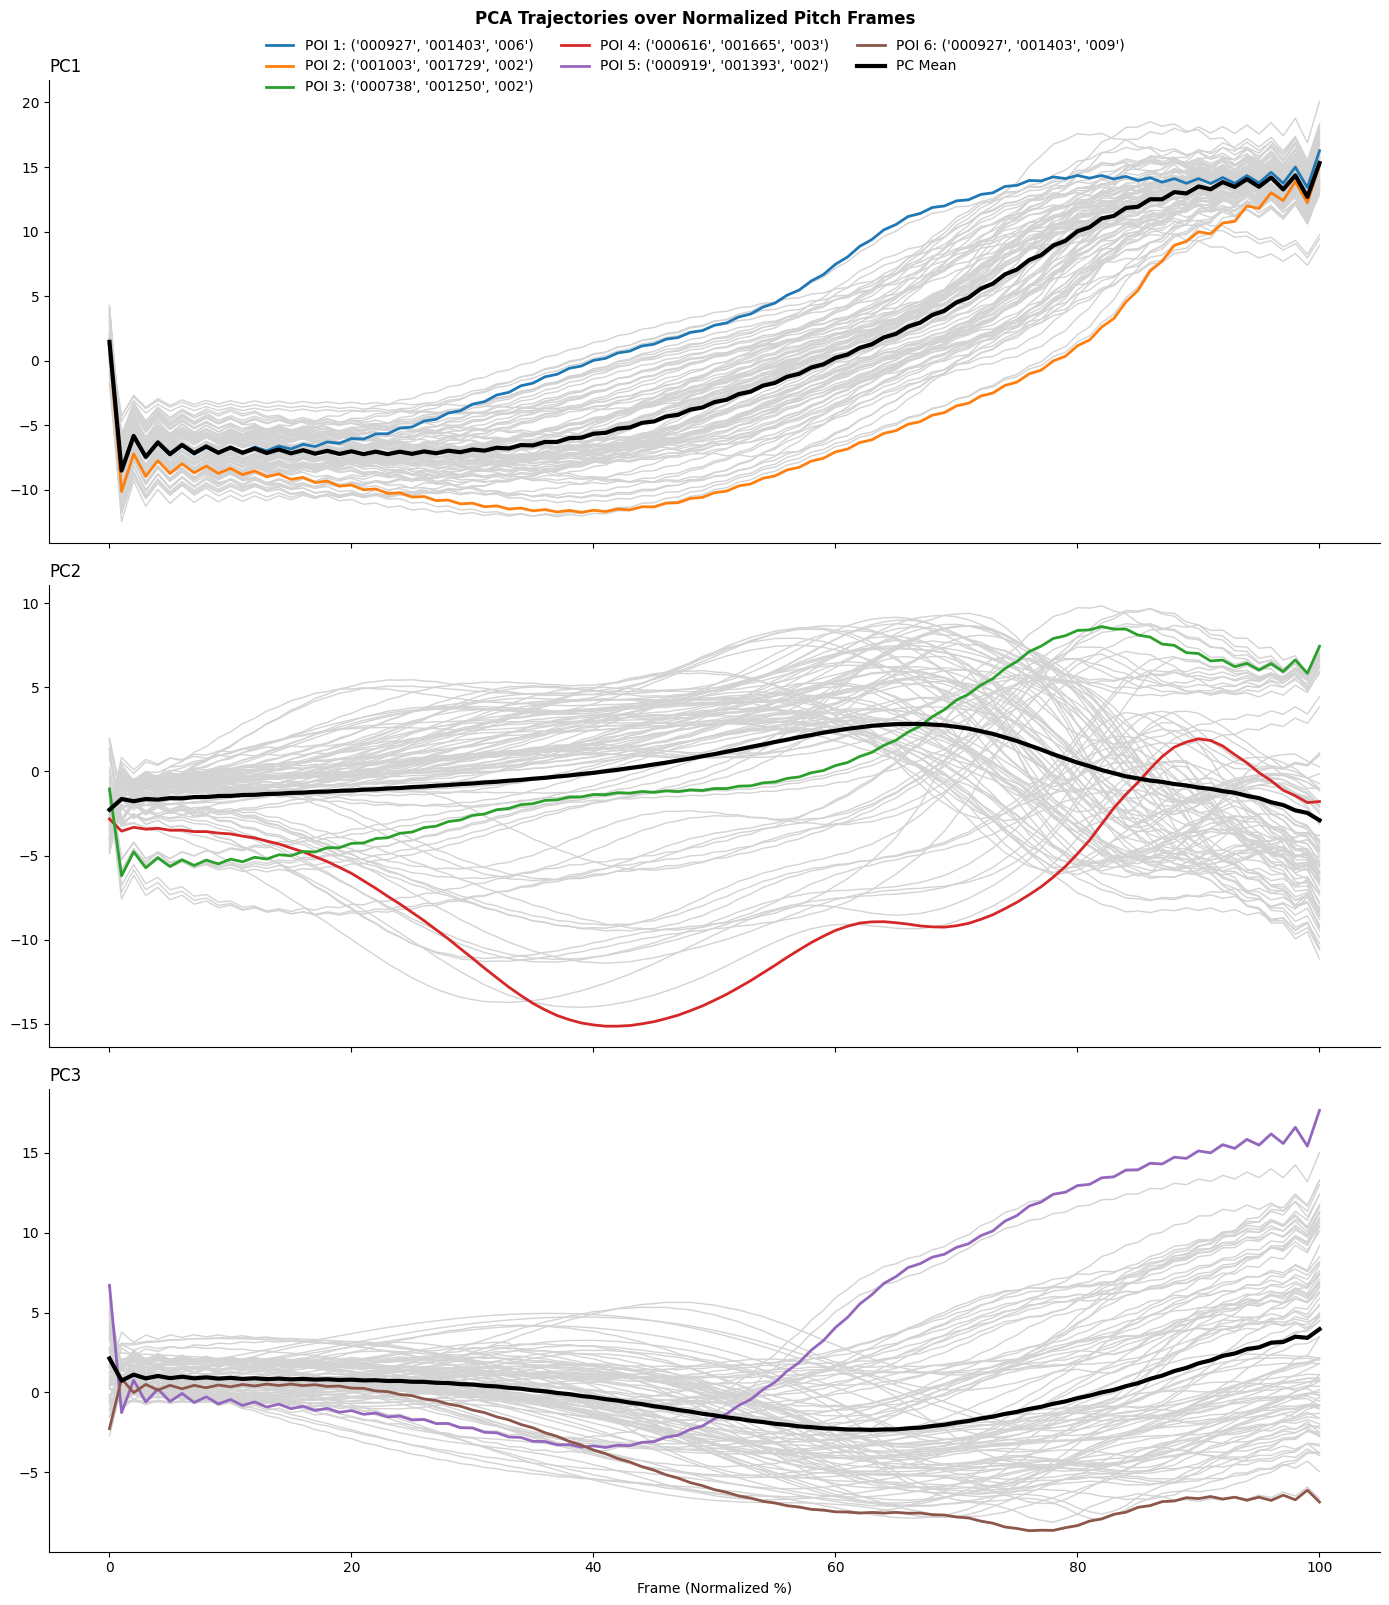

In [14]:
# Initialize subplots
fig, axes = plt.subplots(nrows = 3, ncols = 1, figsize = (14, 16), sharex = True)

# Loop through each PC
for i, pc in enumerate(pcs):
    ax = axes[i]

    # Plot mean line
    mean_pc = normalized_df.groupby("frame_norm")[pc].mean()
    ax.plot(mean_pc.index, mean_pc.values, color = "black", linewidth = 3, label = "PC Mean", zorder = 3)

    # Loop over each pitch
    for (sess, uid, pid, height, weight, pitchType, pitchSpeed), grp in normalized_df.groupby(
        ["sessionID", "userID", "pitchNum", "height", "weight", "pitchType", "pitchSpeed"], sort=False):

        key = (uid, sess, pid)
        # Color based on whether pitch is a pitch of interest (min or max for the PC)
        if key in poi_to_color and pc in poi_to_pcs[key]:
            color = poi_to_color[key]
            lw = 2
            zorder = 2
            label = f"POI {pitch_of_interest.index(key)+1}"
        else:
            color = "lightgray"
            lw = 1
            zorder = 1
            label = ''

        # Plot pitch line
        ax.plot(grp["frame_norm"], grp[pc], color=color, linewidth=lw, zorder=zorder, label=label)

    ax.set_title(f"{pc}", loc="left")
    sns.despine(ax = ax, top = True, right = True)

# Create a collective legend
handles, labels = [], []
for poi in pitch_of_interest:
    handles.append(ax.plot([], [], color = poi_to_color[poi], lw = 2)[0])
    labels.append(f"POI {pitch_of_interest.index(poi) + 1}: {poi}")
handles.append(ax.plot([], [], color="black", lw = 3)[0])
labels.append("PC Mean")

fig.legend(handles, labels, loc = "upper center", frameon = False, ncol = 3,
           bbox_to_anchor=(0.5, 0.99))

axes[-1].set_xlabel("Frame (Normalized %)")
fig.suptitle("PCA Trajectories over Normalized Pitch Frames", ha="center", weight='bold', y = 1)
plt.tight_layout()
plt.savefig("./plots/pca_plot.png")
plt.show()


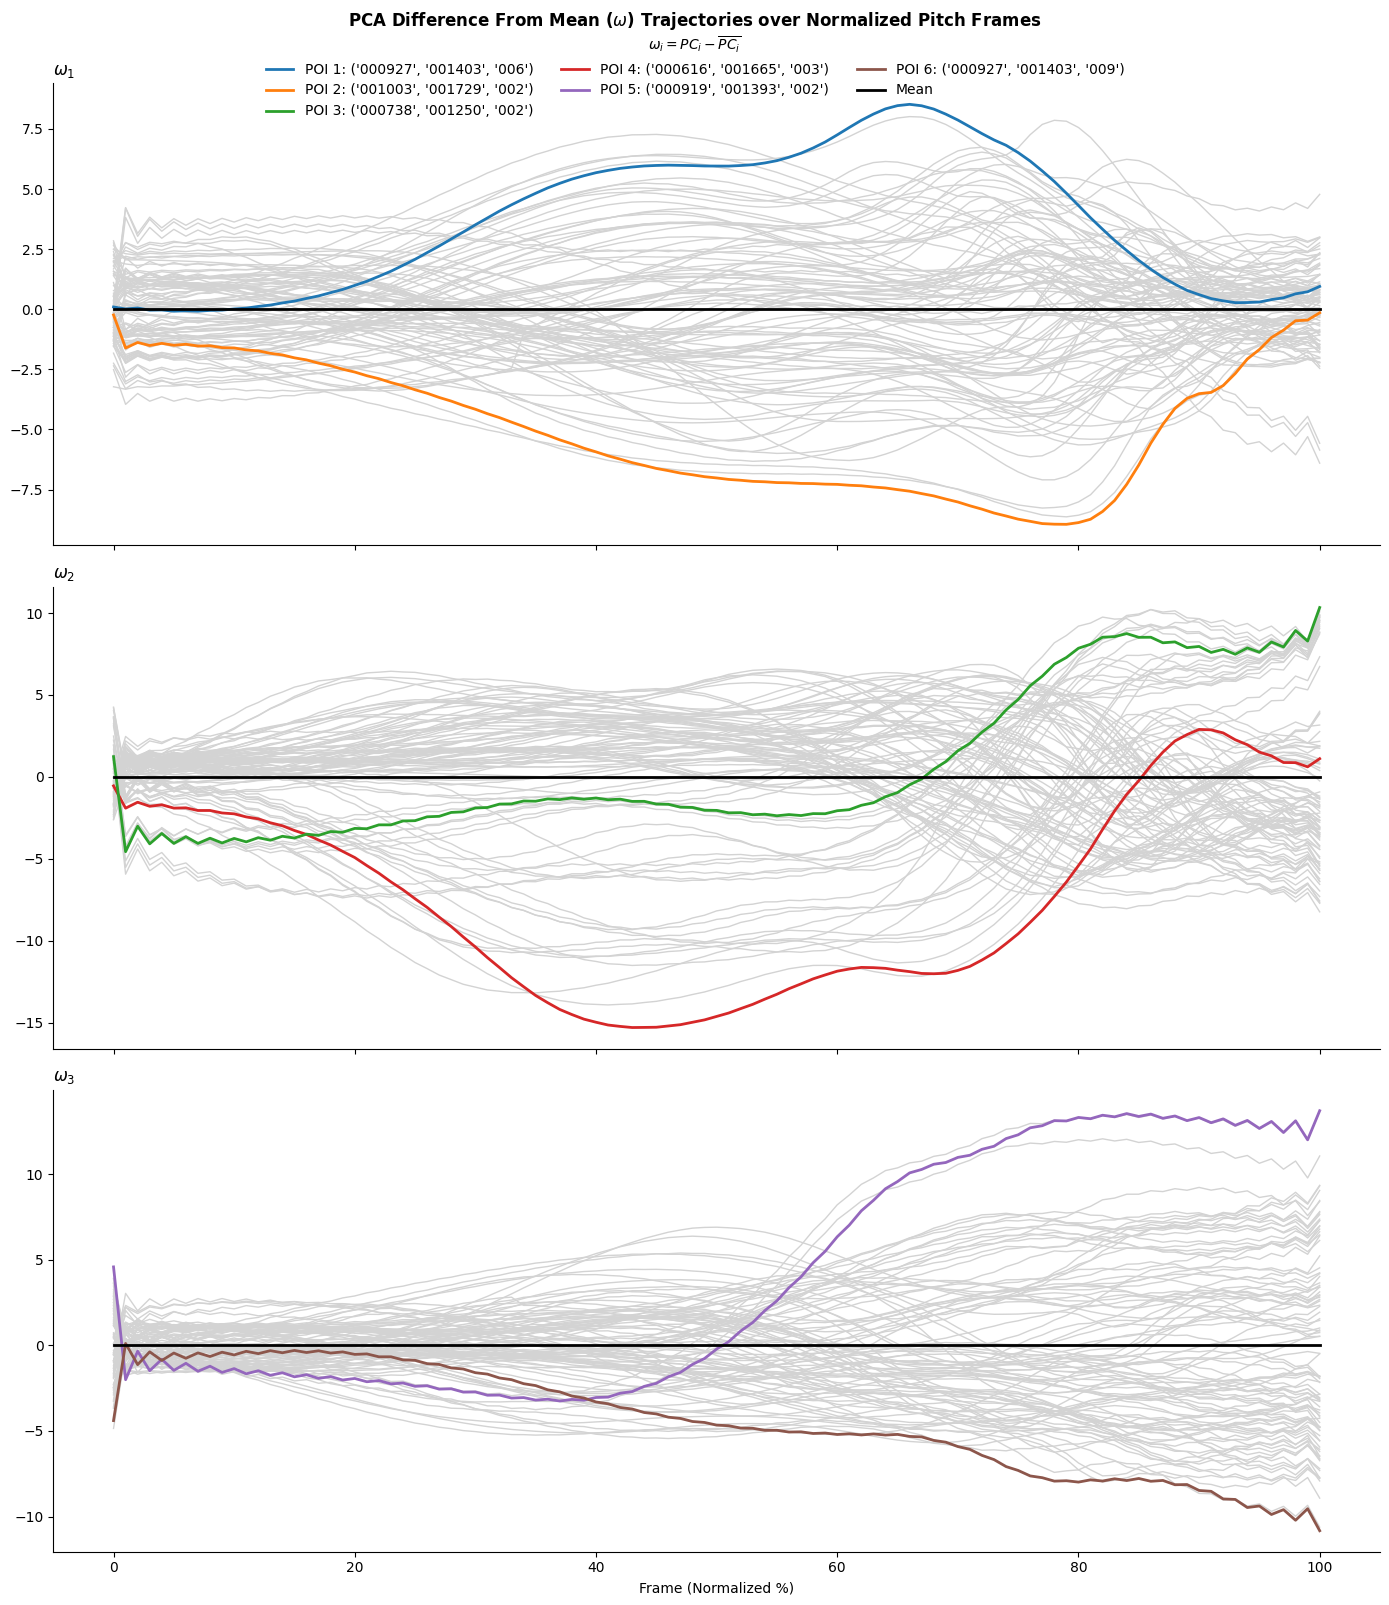

In [15]:
# LaTeX for w_i
deltas = [r"$\omega_1$", r"$\omega_2$", r"$\omega_3$"]
pca_to_delta = dict(zip(pcs, deltas))

# Initialize subplots
fig, axes = plt.subplots(nrows = 3, ncols = 1, figsize = (14,16), sharex = True)

# Loop over each PC
for i, pc in enumerate(pcs):
    ax = axes[i]

    # Plot mean line
    mean_pc = merged.groupby("frame_norm")[f"{pc}_diff"].mean()
    ax.plot(mean_pc.index, mean_pc.values, color="black", linewidth=2, label="Mean", zorder=3)

    # Loop over each pitch
    for (sess, uid, pid, height, weight, pitchType, pitchSpeed), grp in merged.groupby(
        ["sessionID","userID","pitchNum","height","weight","pitchType","pitchSpeed"], sort=False):

        key = (uid, sess, pid)
        # Color based on whether pitch is a POI (min/max for that PC)
        if key in poi_to_color and pc in poi_to_pcs[key]:
            color = poi_to_color[key]
            lw = 2
            zorder = 2
            label = f"POI {poi_records.index(next(r for r in poi_records if r['pitch_of_interest']==key))+1}"
        else:
            color = "lightgray"
            lw = 1
            zorder = 1
            label = ''

        # Plot pitch line
        ax.plot(grp["frame_norm"], grp[f"{pc}_diff"], color=color, linewidth=lw, zorder=zorder, label=label)

    ax.set_title(f"{pca_to_delta[pc]}", loc="left")
    sns.despine(ax=ax, top=True, right=True)

# Create a collective legend
handles, labels = [], []
for r in poi_records:
    poi = r["pitch_of_interest"]
    handles.append(ax.plot([], [], color = poi_to_color[poi], lw = 2)[0])
    labels.append(f"POI {r['POI']}: {poi}")
handles.append(ax.plot([], [], color = "black", lw = 2)[0])
labels.append("Mean")

fig.legend(handles, labels, loc = "upper center", frameon = False, ncol = 3, bbox_to_anchor = (0.5,0.975))

axes[-1].set_xlabel("Frame (Normalized %)")
fig.suptitle(f"PCA Difference From Mean ($\omega$) Trajectories over Normalized Pitch Frames", 
             ha="center", weight='bold', y=1.0)
fig.text(0.5, 0.975, r"$\omega_i = PC_i - \overline{PC_i}$", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("./plots/diff_plot.png")
plt.show()


In [18]:
def singleview(pitch_number):
    # Pitch selection
    userID = pitch_of_interest[pitch_number][0]
    sessionID = pitch_of_interest[pitch_number][1]
    pitchNum = pitch_of_interest[pitch_number][2]

    # Filter data to selected pitch
    sel = data[
        (data['userID'] == userID) &
        (data['sessionID'] == sessionID) &
        (data['pitchNum'] == pitchNum)
    ].copy()
    
    # Ensure chronological frame order
    sel = sel.sort_values('frame')


    # Get first frame (0)
    first_frame = sel['frame'].min()

    # Compute first-frame mean 
    first_frame_mean_y = sel[sel['frame'] == first_frame]['y'].mean()

    # Subtract first-frame mean from all frames (centers all pitches to same starting point mean(y) = 0)
    sel['y'] = sel['y'] - first_frame_mean_y


    # Get metadata out of sel
    height = sel['height'].iloc[0]
    weight = sel['weight'].iloc[0]
    pitchType = sel['pitchType'].iloc[0]
    pitchSpeed = str(int(sel['pitchSpeed'].iloc[0]*10))
    hand = sel["p_throws"].iloc[0]


    # Build marker label-to-index mapping directly from data
    unique_markers = sorted(sel['markerID'].unique())
    marker_to_idx = {m: i for i, m in enumerate(unique_markers)}

    def get_idx(label):
        return marker_to_idx.get(label)


    # Convert dataframe to points array for animation
    unique_frames = sorted(sel['frame'].unique())
    num_markers = len(unique_markers)
    num_frames = len(unique_frames)

    marker_to_idx = {marker: i for i, marker in enumerate(unique_markers)}
    frame_to_idx = {frame: i for i, frame in enumerate(unique_frames)}

    points = np.full((3, num_markers, num_frames), np.nan)
    
    # Get x, y, z location of each point
    for _, row in sel.iterrows():
        m_idx = marker_to_idx[row['markerID']]
        f_idx = frame_to_idx[row['frame']]
        points[0, m_idx, f_idx] = row['x']
        points[1, m_idx, f_idx] = row['y']
        points[2, m_idx, f_idx] = row['z']

    # Define connections
    skeleton_connections_labels = [
        # Head and Neck
        (get_idx('LBHD'), get_idx('LFHD')), # Left Head
        (get_idx('RBHD'), get_idx('RFHD')), # Right Head
        (get_idx('LFHD'), get_idx('RFHD')), # Forehead
        (get_idx('LBHD'), get_idx('RBHD')), # Back of Head
        (get_idx('C7'), get_idx('STRN')),  # Neck to Sternum (approx. upper torso center)
        (get_idx('C7'), get_idx('CLAV')),  # C7 to Clavicle (upper spine to shoulder girdle)
        
        # Torso
        (get_idx('STRN'), get_idx('CLAV')), # Sternum to Clavicle
        (get_idx('CLAV'), get_idx('LSHO')), # Clavicle to Left Shoulder
        (get_idx('CLAV'), get_idx('RSHO')), # Clavicle to Right Shoulder
        (get_idx('LSHO'), get_idx('RSHO')), # Across shoulders
        (get_idx('LSHO'), get_idx('LASI')), # Left Shoulder to Left ASIS (approx. body side)
        (get_idx('RSHO'), get_idx('RASI')), # Right Shoulder to Right ASIS
        (get_idx('LASI'), get_idx('RASI')), # Across hips
        (get_idx('LPSI'), get_idx('RPSI')), # Across posterior hips (if available, good for pelvis)
        (get_idx('LASI'), get_idx('LPSI')), # Left ASIS to Left PSIS
        (get_idx('RASI'), get_idx('RPSI')), # Right ASIS to Right PSIS
        
        # Left Arm
        (get_idx('LSHO'), get_idx('LUPA')), # Shoulder to Upper Arm (Bicep)
        (get_idx('LUPA'), get_idx('LELB')), # Upper Arm to Elbow
        (get_idx('LELB'), get_idx('LFRM')), # Elbow to Forearm (Radius/Ulna)
        (get_idx('LFRM'), get_idx('LWRA')), # Forearm to Wrist A
        (get_idx('LWRA'), get_idx('LWRB')), # Wrist A to Wrist B
        (get_idx('LWRB'), get_idx('LFIN')), # Wrist B to Finger
        
        # Right Arm
        (get_idx('RSHO'), get_idx('RUPA')), # Shoulder to Upper Arm (Bicep)
        (get_idx('RUPA'), get_idx('RELB')), # Upper Arm to Elbow
        (get_idx('RELB'), get_idx('RFRM')), # Elbow to Forearm (Radius/Ulna)
        (get_idx('RFRM'), get_idx('RWRA')), # Forearm to Wrist A
        (get_idx('RWRA'), get_idx('RWRB')), # Wrist A to Wrist B
        (get_idx('RWRB'), get_idx('RFIN')), # Wrist B to Finger

        # Left Leg
        (get_idx('LASI'), get_idx('LTHI')), # ASIS to Thigh (femur)
        (get_idx('LTHI'), get_idx('LKNE')), # Thigh to Knee
        (get_idx('LKNE'), get_idx('LTIB')), # Knee to Tibia
        (get_idx('LTIB'), get_idx('LANK')), # Tibia to Ankle
        (get_idx('LANK'), get_idx('LHEE')), # Ankle to Heel
        (get_idx('LANK'), get_idx('LTOE')), # Ankle to Toe
        (get_idx('LHEE'), get_idx('LTOE')), # Heel to Toe
        (get_idx('LANK'), get_idx('LMANK')), # Left Ankle to Medial Ankle (if LMANK is medial)
        
        # Right Leg
        (get_idx('RASI'), get_idx('RTHI')), # ASIS to Thigh (femur)
        (get_idx('RTHI'), get_idx('RKNE')), # Thigh to Knee
        (get_idx('RKNE'), get_idx('RTIB')), # Knee to Tibia
        (get_idx('RTIB'), get_idx('RANK')), # Tibia to Ankle
        (get_idx('RANK'), get_idx('RHEE')), # Ankle to Heel
        (get_idx('RANK'), get_idx('RTOE')), # Ankle to Toe
        (get_idx('RHEE'), get_idx('RTOE')), # Heel to Toe
        (get_idx('RANK'), get_idx('RMANK')) # Right Ankle to Medial Ankle (if RMANK is medial)
    ]

    # Filter out any connections where one or both of the markers were not found
    skeleton_connections = [conn for conn in skeleton_connections_labels if all(c is not None for c in conn)]

    # Set up plot
    fig = plt.figure(figsize = (10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Set consistent axis limits and viewing angle
    x_min, x_max = np.nanmin(points[0, :, :]), np.nanmax(points[0, :, :])
    y_min, y_max = np.nanmin(points[1, :, :]), np.nanmax(points[1, :, :])
    z_min, z_max = np.nanmin(points[2, :, :]), np.nanmax(points[2, :, :])
        
    # Add a small buffer to the limits
    buffer = 0.1 * (max(x_max-x_min, y_max-y_min, z_max-z_min) or 1) 
    ax.set_xlim([x_min - buffer, x_max + buffer])
    ax.set_ylim([y_min - buffer, y_max + buffer])
    ax.set_zlim([z_min - buffer, z_max + buffer])

    ax.set_xlabel('X Axis'); ax.set_ylabel('Y Axis'); ax.set_zlabel('Z Axis')
    ax.view_init(elev = 30, azim = -55)


    # Initialize scatter plot for the markers (frame = 0)
    scatter = ax.scatter(points[0, :, 0], points[1, :, 0], points[2, :, 0], alpha = 0.75, color = 'royalblue', label = 'Markers')
    title = ax.set_title('Frame 0')

    # Initialize line plots for the skeleton (frmae = 0)
    lines = []
    for p1_idx, p2_idx in skeleton_connections:
        x = points[0, [p1_idx, p2_idx], 0]
        y = points[1, [p1_idx, p2_idx], 0]
        z = points[2, [p1_idx, p2_idx], 0]
        line, = ax.plot(x, y, z, color='lightcoral', lw=2) 
        lines.append(line)

    # Update function for animation
    def update(frame):

        # Update marker positions
        scatter._offsets3d = (points[0, :, frame], points[1, :, frame], points[2, :, frame])
        title.set_text(f'Handedness: {hand} | Frame: {frame} | Percentage of Motion: {(frame/num_frames) * 100:.1f}%')

        # Update skeleton line positions
        for i, (p1_idx, p2_idx) in enumerate(skeleton_connections):
            x = points[0, [p1_idx, p2_idx], frame]
            y = points[1, [p1_idx, p2_idx], frame]
            z = points[2, [p1_idx, p2_idx], frame]
            
            lines[i].set_data(x, y)
            lines[i].set_3d_properties(z)
        
        # Print out progress every 50 frames
        if frame % 50 == 0:
            print(f"On frame {frame} of animation")

        # Return updates
        return [scatter, title] + lines

    # Create and save animation
    num_frames = points.shape[2]
    ani = FuncAnimation(fig, update, frames=num_frames, interval=15, blit=False)

    print("Saving animation... please wait.")
    ani.save(f'./animations/singleview/{userID}_{sessionID}_{pitchNum}.mp4', writer ='ffmpeg', fps = 60)
    print(f"Animation saved as {userID}_{sessionID}_{pitchNum}.mp4'")

Starting animation 0
Saving animation... please wait.
On frame 0 of animation
On frame 0 of animation
On frame 50 of animation
On frame 100 of animation
On frame 150 of animation
On frame 200 of animation
On frame 250 of animation
On frame 300 of animation
On frame 350 of animation
On frame 400 of animation
Animation saved as 000927_001403_006.mp4'
Starting animation 1
Saving animation... please wait.
On frame 0 of animation
On frame 0 of animation
On frame 50 of animation
On frame 100 of animation
On frame 150 of animation
On frame 200 of animation
On frame 250 of animation
On frame 300 of animation
On frame 350 of animation
On frame 400 of animation
On frame 450 of animation
On frame 500 of animation
On frame 550 of animation
On frame 600 of animation
On frame 650 of animation
On frame 700 of animation
On frame 750 of animation
On frame 800 of animation
Animation saved as 001003_001729_002.mp4'
Starting animation 2
Saving animation... please wait.
On frame 0 of animation
On frame 0 o

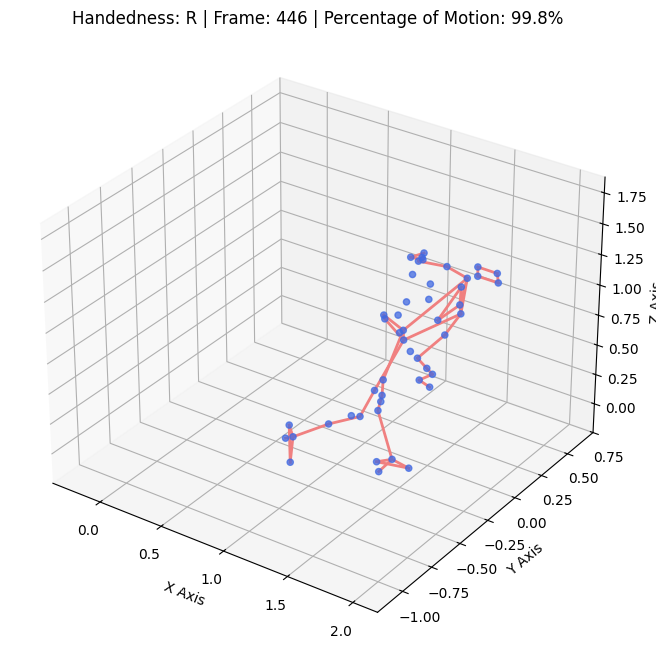

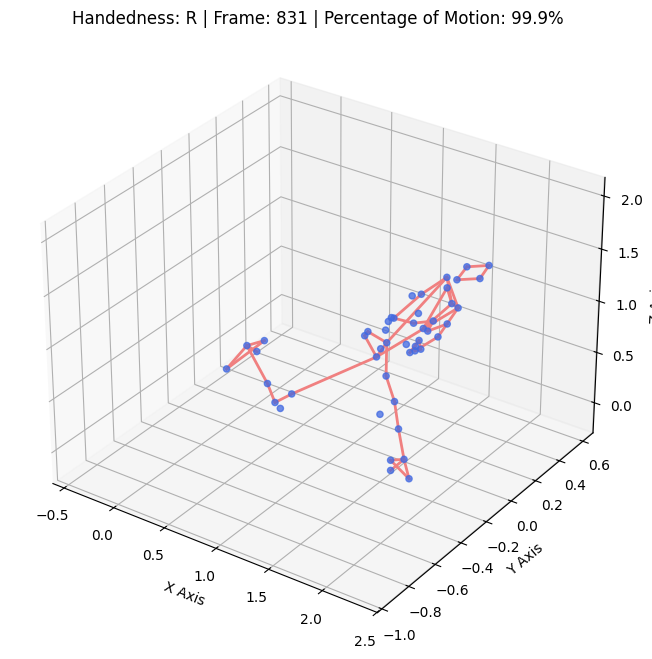

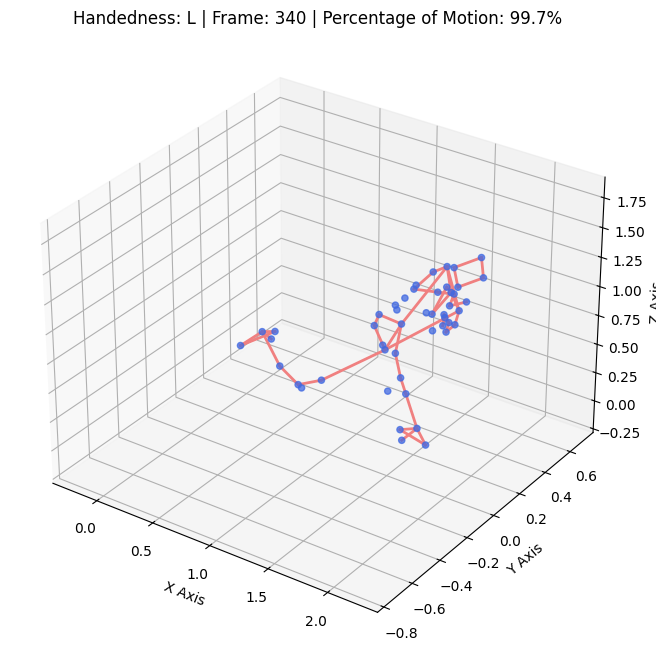

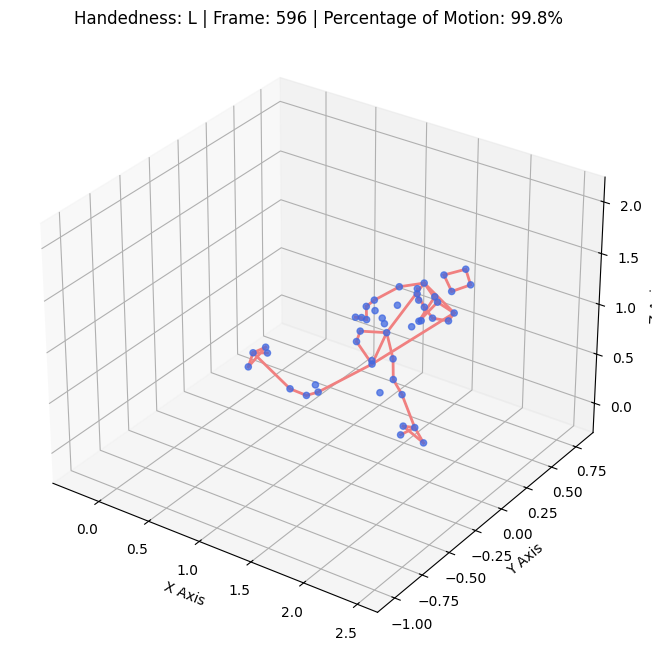

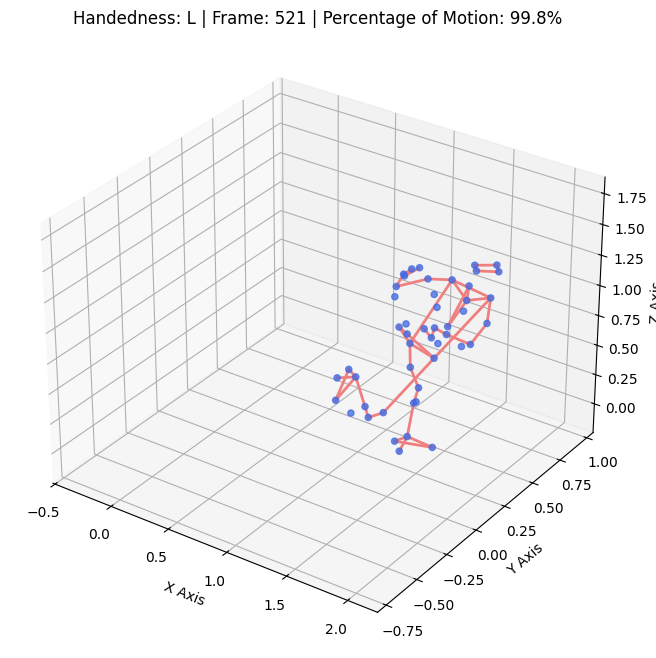

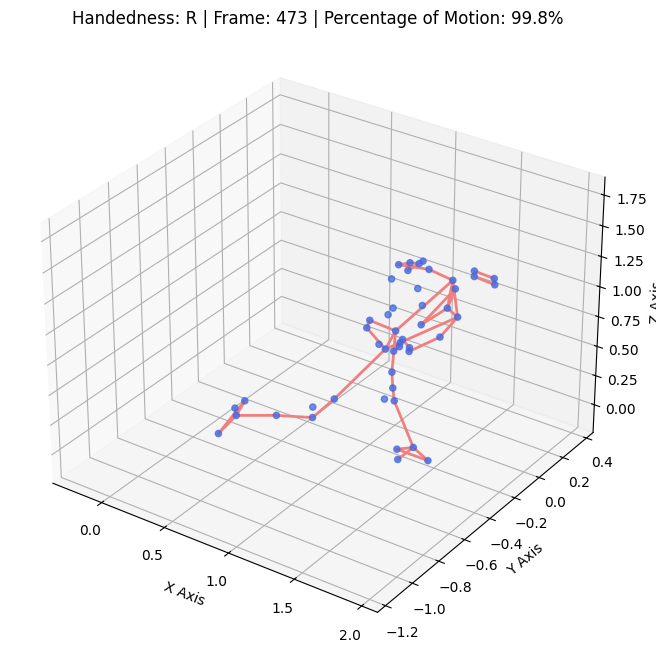

In [19]:
for i in range(len(pitch_of_interest)):
    print(f"Starting animation {i}")
    singleview(pitch_number = i)
print("Done Animating")

In [20]:
def multiview(data, pitch_number):
    # Pitch selection
    userID = pitch_of_interest[pitch_number][0]
    sessionID = pitch_of_interest[pitch_number][1]
    pitchNum = pitch_of_interest[pitch_number][2]

    # Filter data to selected pitch
    sel = data[
        (data['userID'] == userID) &
        (data['sessionID'] == sessionID) &
        (data['pitchNum'] == pitchNum)
    ].copy()

    # Ensure chronological frame order
    sel = sel.sort_values('frame')

    # Get first frame (0)
    first_frame = sel['frame'].min()

    # Compute first-frame mean 
    first_frame_mean_y = sel[sel['frame'] == first_frame]['y'].mean()

    # Subtract first-frame mean from all frames (centers all pitches to same starting point mean(y) = 0)
    sel['y'] = sel['y'] - first_frame_mean_y


    # Get metadata out of sel
    height = sel['height'].iloc[0]
    weight = sel['weight'].iloc[0]
    pitchType = sel['pitchType'].iloc[0]
    pitchSpeed = str(int(sel['pitchSpeed'].iloc[0]*10))
    hand = sel["p_throws"].iloc[0]

    # Build marker label-to-index mapping directly from data
    unique_markers = sorted(sel['markerID'].unique())
    marker_to_idx = {m: i for i, m in enumerate(unique_markers)}

    def get_idx(label):
        return marker_to_idx.get(label)


    # Convert dataframe to points array for animation
    # points shape should be (3, num_markers, num_frames)
    unique_frames = sorted(sel['frame'].unique())
    num_markers = len(unique_markers)
    num_frames = len(unique_frames)

    marker_to_idx = {marker: i for i, marker in enumerate(unique_markers)}
    frame_to_idx = {frame: i for i, frame in enumerate(unique_frames)}

    points = np.full((3, num_markers, num_frames), np.nan)

    # Get x, y, z location of each point
    for _, row in sel.iterrows():
        m_idx = marker_to_idx[row['markerID']]
        f_idx = frame_to_idx[row['frame']]
        points[0, m_idx, f_idx] = row['x']
        points[1, m_idx, f_idx] = row['y']
        points[2, m_idx, f_idx] = row['z']

    # Define connections
    skeleton_connections_labels = [
        # Head and Neck
        (get_idx('LBHD'), get_idx('LFHD')), # Left Head
        (get_idx('RBHD'), get_idx('RFHD')), # Right Head
        (get_idx('LFHD'), get_idx('RFHD')), # Forehead
        (get_idx('LBHD'), get_idx('RBHD')), # Back of Head
        (get_idx('C7'), get_idx('STRN')),  # Neck to Sternum (approx. upper torso center)
        (get_idx('C7'), get_idx('CLAV')),  # C7 to Clavicle (upper spine to shoulder girdle)
        
        # Torso
        (get_idx('STRN'), get_idx('CLAV')), # Sternum to Clavicle
        (get_idx('CLAV'), get_idx('LSHO')), # Clavicle to Left Shoulder
        (get_idx('CLAV'), get_idx('RSHO')), # Clavicle to Right Shoulder
        (get_idx('LSHO'), get_idx('RSHO')), # Across shoulders
        (get_idx('LSHO'), get_idx('LASI')), # Left Shoulder to Left ASIS (approx. body side)
        (get_idx('RSHO'), get_idx('RASI')), # Right Shoulder to Right ASIS
        (get_idx('LASI'), get_idx('RASI')), # Across hips
        (get_idx('LPSI'), get_idx('RPSI')), # Across posterior hips (if available, good for pelvis)
        (get_idx('LASI'), get_idx('LPSI')), # Left ASIS to Left PSIS
        (get_idx('RASI'), get_idx('RPSI')), # Right ASIS to Right PSIS
        
        # Left Arm
        (get_idx('LSHO'), get_idx('LUPA')), # Shoulder to Upper Arm (Bicep)
        (get_idx('LUPA'), get_idx('LELB')), # Upper Arm to Elbow
        (get_idx('LELB'), get_idx('LFRM')), # Elbow to Forearm (Radius/Ulna)
        (get_idx('LFRM'), get_idx('LWRA')), # Forearm to Wrist A
        (get_idx('LWRA'), get_idx('LWRB')), # Wrist A to Wrist B
        (get_idx('LWRB'), get_idx('LFIN')), # Wrist B to Finger
        
        # Right Arm
        (get_idx('RSHO'), get_idx('RUPA')), # Shoulder to Upper Arm (Bicep)
        (get_idx('RUPA'), get_idx('RELB')), # Upper Arm to Elbow
        (get_idx('RELB'), get_idx('RFRM')), # Elbow to Forearm (Radius/Ulna)
        (get_idx('RFRM'), get_idx('RWRA')), # Forearm to Wrist A
        (get_idx('RWRA'), get_idx('RWRB')), # Wrist A to Wrist B
        (get_idx('RWRB'), get_idx('RFIN')), # Wrist B to Finger

        # Left Leg
        (get_idx('LASI'), get_idx('LTHI')), # ASIS to Thigh (femur)
        (get_idx('LTHI'), get_idx('LKNE')), # Thigh to Knee
        (get_idx('LKNE'), get_idx('LTIB')), # Knee to Tibia
        (get_idx('LTIB'), get_idx('LANK')), # Tibia to Ankle
        (get_idx('LANK'), get_idx('LHEE')), # Ankle to Heel
        (get_idx('LANK'), get_idx('LTOE')), # Ankle to Toe
        (get_idx('LHEE'), get_idx('LTOE')), # Heel to Toe
        (get_idx('LANK'), get_idx('LMANK')), # Left Ankle to Medial Ankle (if LMANK is medial)
        
        # Right Leg
        (get_idx('RASI'), get_idx('RTHI')), # ASIS to Thigh (femur)
        (get_idx('RTHI'), get_idx('RKNE')), # Thigh to Knee
        (get_idx('RKNE'), get_idx('RTIB')), # Knee to Tibia
        (get_idx('RTIB'), get_idx('RANK')), # Tibia to Ankle
        (get_idx('RANK'), get_idx('RHEE')), # Ankle to Heel
        (get_idx('RANK'), get_idx('RTOE')), # Ankle to Toe
        (get_idx('RHEE'), get_idx('RTOE')), # Heel to Toe
        (get_idx('RANK'), get_idx('RMANK')) # Right Ankle to Medial Ankle (if RMANK is medial)
    ]

    # Filter out any connections where one or both of the markers were not found
    skeleton_connections = [conn for conn in skeleton_connections_labels if all(c is not None for c in conn)]

    # Setup figure with multiple subplots (5 views)
    fig = plt.figure(figsize=(20, 12))
    view_angles = [
        (30, -55),     # original
        (0, 0),        # xz plane (flat)
        (0, 90),       # yz plane (flat)
        (0, 180),      # backside xz
        (0, 270)       # backside yz
    ]
    axes = []
    scatters = []
    lines_list = []

    # Axis limits
    x_min, x_max = np.nanmin(points[0]), np.nanmax(points[0])
    y_min, y_max = np.nanmin(points[1]), np.nanmax(points[1])
    z_min, z_max = np.nanmin(points[2]), np.nanmax(points[2])
    buffer = 0.1 * (max(x_max-x_min, y_max-y_min, z_max-z_min) or 1)

    for i, (elev, azim) in enumerate(view_angles):
        ax = fig.add_subplot(2, 3, i+1, projection='3d')
        ax.set_xlim([x_min-buffer, x_max+buffer])
        ax.set_ylim([y_min-buffer, y_max+buffer])
        ax.set_zlim([z_min-buffer, z_max+buffer])
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
        ax.view_init(elev=elev, azim=azim)
        axes.append(ax)

        scatter = ax.scatter(points[0, :, 0], points[1, :, 0], points[2, :, 0], color='royalblue')
        scatters.append(scatter)

        # Lines for skeleton
        lines = []
        for p1_idx, p2_idx in skeleton_connections:
            x = points[0, [p1_idx, p2_idx], 0]
            y = points[1, [p1_idx, p2_idx], 0]
            z = points[2, [p1_idx, p2_idx], 0]
            line, = ax.plot(x, y, z, color='lightcoral', lw=2)
            lines.append(line)
        lines_list.append(lines)

    view_names = ["Overview", "Front", "Side 1", "Side 2", "Back"]
    def update(frame):
        for ax_idx in range(len(axes)):
            scatters[ax_idx]._offsets3d = (points[0, :, frame], points[1, :, frame], points[2, :, frame])
            for i, (p1_idx, p2_idx) in enumerate(skeleton_connections):
                x = points[0, [p1_idx, p2_idx], frame]
                y = points[1, [p1_idx, p2_idx], frame]
                z = points[2, [p1_idx, p2_idx], frame]
                lines_list[ax_idx][i].set_data(x, y)
                lines_list[ax_idx][i].set_3d_properties(z)

            axes[ax_idx].set_title(f'Handedness {hand}, {view_names[ax_idx]}, Frame {frame}, Percentage of Motion: {(frame/num_frames) * 100:.1f}%')
        # Return all updated artists
        if frame % 50 == 0:
            print(f"On frame {frame} of animation")
        return scatters + [line for lines in lines_list for line in lines]

    ani = FuncAnimation(fig, update, frames = num_frames, interval = 15, blit = False)
    ani.save(f'./animations/multiview/{userID}_{sessionID}_{pitchNum}_multiangle.mp4', writer='ffmpeg', fps=60)
    print(f"Animation saved as {userID}_{sessionID}_{pitchNum}_multiangle.mp4")

In [21]:
# multiview(0)

In [22]:
un_normalized_mean_df = scores_df.groupby("frame")[["PC1", "PC2", "PC3"]].mean().reset_index()
un_normalized_mean_df = un_normalized_mean_df.rename(columns = {'PC1' : 'PC1_mean', 'PC2' : 'PC2_mean', 'PC3' : 'PC3_mean'})
un_normalized_mean_df.head(2)

,frame,PC1_mean,PC2_mean,PC3_mean
0,0,-6.753346,-1.778783,0.988585
1,1,-6.757169,-1.773009,0.988865


In [35]:
recon_scaled = pca.inverse_transform(mean_df[['PC1_mean', 'PC2_mean', 'PC3_mean']].values)
recon_orig = scaler.inverse_transform(recon_scaled)
recon_df_wide = pd.DataFrame(recon_orig, columns = feature_cols)
recon_df_wide['frame'] = range(mean_df.shape[0])
recon_df_long = recon_df_wide.melt(
        id_vars='frame', 
        var_name='marker_coord', 
        value_name='value'
    )
# Split 'x_marker1' into 'x' and '1'
coord_marker = recon_df_long['marker_coord'].str.split('_marker', expand=True)
recon_df_long['coord'] = coord_marker[0]
recon_df_long['markerID'] = coord_marker[1].astype(str)
    
# Pivot to final format: (frame, markerID, x, y, z)
average_pitch_coords_df = (
    recon_df_long
    .pivot_table(index=['frame', 'markerID'], columns='coord', values='value')
    .reset_index()
)
average_pitch_coords_df.head()

coord,frame,markerID,x,y,z
0,0,C7,0.694209,0.048913,1.391205
1,0,CLAV,0.702362,0.101279,1.285331
2,0,LANK,0.602227,-0.078846,0.222018
3,0,LASI,0.690231,-0.003356,0.939581
4,0,LBAK,0.691792,-0.025169,1.247286


In [36]:
def singleview_theoretical(sel, name):
    # Ensure chronological frame order
    sel = sel.sort_values('frame')

    # Build marker label-to-index mapping directly from data
    unique_markers = sorted(sel['markerID'].unique())
    marker_to_idx = {m: i for i, m in enumerate(unique_markers)}

    def get_idx(label):
        return marker_to_idx.get(label)


    # Convert dataframe to points array for animation
    unique_frames = sorted(sel['frame'].unique())
    num_markers = len(unique_markers)
    num_frames = len(unique_frames)
    frame_to_idx = {frame: i for i, frame in enumerate(unique_frames)}

    points = np.full((3, num_markers, num_frames), np.nan)
    
    # Get x, y, z location of each point
    for _, row in sel.iterrows():
        m_idx = marker_to_idx[row['markerID']]
        f_idx = frame_to_idx[row['frame']]
        points[0, m_idx, f_idx] = row['x']
        points[1, m_idx, f_idx] = row['y']
        points[2, m_idx, f_idx] = row['z']

    # Define connections
    skeleton_connections_labels = [
        # Head and Neck
        (get_idx('LBHD'), get_idx('LFHD')), # Left Head
        (get_idx('RBHD'), get_idx('RFHD')), # Right Head
        (get_idx('LFHD'), get_idx('RFHD')), # Forehead
        (get_idx('LBHD'), get_idx('RBHD')), # Back of Head
        (get_idx('C7'), get_idx('STRN')),  # Neck to Sternum (approx. upper torso center)
        (get_idx('C7'), get_idx('CLAV')),  # C7 to Clavicle (upper spine to shoulder girdle)
        
        # Torso
        (get_idx('STRN'), get_idx('CLAV')), # Sternum to Clavicle
        (get_idx('CLAV'), get_idx('LSHO')), # Clavicle to Left Shoulder
        (get_idx('CLAV'), get_idx('RSHO')), # Clavicle to Right Shoulder
        (get_idx('LSHO'), get_idx('RSHO')), # Across shoulders
        (get_idx('LSHO'), get_idx('LASI')), # Left Shoulder to Left ASIS (approx. body side)
        (get_idx('RSHO'), get_idx('RASI')), # Right Shoulder to Right ASIS
        (get_idx('LASI'), get_idx('RASI')), # Across hips
        (get_idx('LPSI'), get_idx('RPSI')), # Across posterior hips (if available, good for pelvis)
        (get_idx('LASI'), get_idx('LPSI')), # Left ASIS to Left PSIS
        (get_idx('RASI'), get_idx('RPSI')), # Right ASIS to Right PSIS
        
        # Left Arm
        (get_idx('LSHO'), get_idx('LUPA')), # Shoulder to Upper Arm (Bicep)
        (get_idx('LUPA'), get_idx('LELB')), # Upper Arm to Elbow
        (get_idx('LELB'), get_idx('LFRM')), # Elbow to Forearm (Radius/Ulna)
        (get_idx('LFRM'), get_idx('LWRA')), # Forearm to Wrist A
        (get_idx('LWRA'), get_idx('LWRB')), # Wrist A to Wrist B
        (get_idx('LWRB'), get_idx('LFIN')), # Wrist B to Finger
        
        # Right Arm
        (get_idx('RSHO'), get_idx('RUPA')), # Shoulder to Upper Arm (Bicep)
        (get_idx('RUPA'), get_idx('RELB')), # Upper Arm to Elbow
        (get_idx('RELB'), get_idx('RFRM')), # Elbow to Forearm (Radius/Ulna)
        (get_idx('RFRM'), get_idx('RWRA')), # Forearm to Wrist A
        (get_idx('RWRA'), get_idx('RWRB')), # Wrist A to Wrist B
        (get_idx('RWRB'), get_idx('RFIN')), # Wrist B to Finger

        # Left Leg
        (get_idx('LASI'), get_idx('LTHI')), # ASIS to Thigh (femur)
        (get_idx('LTHI'), get_idx('LKNE')), # Thigh to Knee
        (get_idx('LKNE'), get_idx('LTIB')), # Knee to Tibia
        (get_idx('LTIB'), get_idx('LANK')), # Tibia to Ankle
        (get_idx('LANK'), get_idx('LHEE')), # Ankle to Heel
        (get_idx('LANK'), get_idx('LTOE')), # Ankle to Toe
        (get_idx('LHEE'), get_idx('LTOE')), # Heel to Toe
        (get_idx('LANK'), get_idx('LMANK')), # Left Ankle to Medial Ankle (if LMANK is medial)
        
        # Right Leg
        (get_idx('RASI'), get_idx('RTHI')), # ASIS to Thigh (femur)
        (get_idx('RTHI'), get_idx('RKNE')), # Thigh to Knee
        (get_idx('RKNE'), get_idx('RTIB')), # Knee to Tibia
        (get_idx('RTIB'), get_idx('RANK')), # Tibia to Ankle
        (get_idx('RANK'), get_idx('RHEE')), # Ankle to Heel
        (get_idx('RANK'), get_idx('RTOE')), # Ankle to Toe
        (get_idx('RHEE'), get_idx('RTOE')), # Heel to Toe
        (get_idx('RANK'), get_idx('RMANK')) # Right Ankle to Medial Ankle (if RMANK is medial)
    ]

    # Filter out any connections where one or both of the markers were not found
    skeleton_connections = [conn for conn in skeleton_connections_labels if all(c is not None for c in conn)]

    # Set up plot
    fig = plt.figure(figsize = (10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Set consistent axis limits and viewing angle
    x_min, x_max = np.nanmin(points[0, :, :]), np.nanmax(points[0, :, :])
    y_min, y_max = np.nanmin(points[1, :, :]), np.nanmax(points[1, :, :])
    z_min, z_max = np.nanmin(points[2, :, :]), np.nanmax(points[2, :, :])
        
    # Add a small buffer to the limits
    buffer = 0.1 * (max(x_max-x_min, y_max-y_min, z_max-z_min) or 1) 
    ax.set_xlim([x_min - buffer, x_max + buffer])
    ax.set_ylim([y_min - buffer, y_max + buffer])
    ax.set_zlim([z_min - buffer, z_max + buffer])

    ax.set_xlabel('X Axis'); ax.set_ylabel('Y Axis'); ax.set_zlabel('Z Axis')
    ax.view_init(elev = 30, azim = -55)


    # Initialize scatter plot for the markers (frame = 0)
    scatter = ax.scatter(points[0, :, 0], points[1, :, 0], points[2, :, 0], alpha = 0.75, color = 'royalblue', label = 'Markers')
    title = ax.set_title('Frame 0')

    # Initialize line plots for the skeleton (frmae = 0)
    lines = []
    for p1_idx, p2_idx in skeleton_connections:
        x = points[0, [p1_idx, p2_idx], 0]
        y = points[1, [p1_idx, p2_idx], 0]
        z = points[2, [p1_idx, p2_idx], 0]
        line, = ax.plot(x, y, z, color='lightcoral', lw=2) 
        lines.append(line)

    # Update function for animation
    def update(frame):

        # Update marker positions
        scatter._offsets3d = (points[0, :, frame], points[1, :, frame], points[2, :, frame])
        title.set_text(f'| Frame: {frame} | Percentage of Motion: {(frame/num_frames) * 100:.1f}%')

        # Update skeleton line positions
        for i, (p1_idx, p2_idx) in enumerate(skeleton_connections):
            x = points[0, [p1_idx, p2_idx], frame]
            y = points[1, [p1_idx, p2_idx], frame]
            z = points[2, [p1_idx, p2_idx], frame]
            
            lines[i].set_data(x, y)
            lines[i].set_3d_properties(z)
        
        # Print out progress every 50 frames
        if frame % 50 == 0:
            print(f"On frame {frame} of animation")

        # Return updates
        return [scatter, title] + lines

    # Create and save animation
    num_frames = points.shape[2]
    ani = FuncAnimation(fig, update, frames=num_frames, interval=15, blit=False)

    print("Saving animation... please wait.")
    ani.save(f'./animations/theoretical/{name}.mp4', writer ='ffmpeg', fps = 60)
    print(f"Animation saved as {name}.mp4'")

Saving animation... please wait.
On frame 0 of animation
On frame 0 of animation
On frame 50 of animation
On frame 100 of animation
Animation saved as testrun6.mp4'


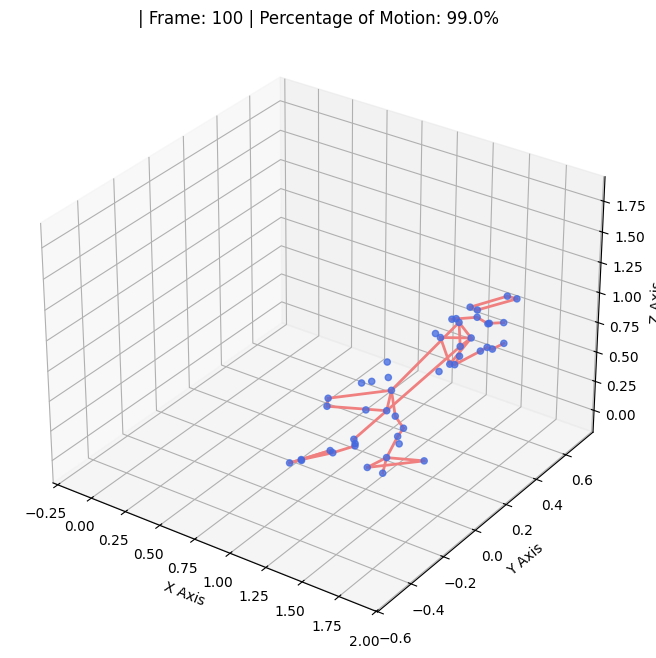

In [37]:
singleview_theoretical(average_pitch_coords_df, "testrun6")